In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from analyze_six import preprocess_image, to_gray
import re
import os
import random
from numpy.lib.stride_tricks import sliding_window_view
import cv2

In [2]:

def best_affine_residual(profile, template):
    """
    Fits profile ≈ a * template + b.
    Returns fitted profile, residual, and normalized residual score.
    """
    p = profile.astype(float)
    t = template.astype(float)

    X = np.column_stack([t, np.ones_like(t)])
    a, b = np.linalg.lstsq(X, p, rcond=None)[0]

    fit = a * t + b
    resid = p - fit
    # normalized residual, so bright columns do not automatically score higher
    score = np.sqrt(np.mean(resid ** 2)) / (np.std(p) + 1e-9)

    return fit, resid, score

In [3]:
def background_residual_map(gray, bg_gray, y0=None, y1=None):
    """
    gray: current image, grayscale
    bg_gray: pure background image, same alignment/rotation/crop
    """

    gray = gray.astype(float)
    bg_gray = bg_gray.astype(float)

    h, w = gray.shape
    bh, bw = bg_gray.shape
    h = min(h, bh)
    w = min(w, bw)
    if y0 is None:
        y0 = 0
    if y1 is None:
        y1 = h

    residual_img = np.zeros_like(gray, dtype=float)
    score = np.zeros(w, dtype=float)

    for x in range(w):
        profile = gray[y0:y1, x]
        template = bg_gray[y0:y1, x]

        fit, resid, s = best_affine_residual(profile, template)

        residual_img[y0:y1, x] = resid
        score[x] = s

    return residual_img, score

In [4]:

def zscore(v):
    v = v.astype(float)
    return (v - v.mean()) / (v.std() + 1e-9)


def make_general_laser_template(bg_gray, radius=25, use_derivative=False):
    """
    Builds one canonical vertical laser profile from a pure-background image.

    bg_gray: pure background image, grayscale
    radius: half-height of template window
    """
    bg_gray = bg_gray.astype(float)
    h, w = bg_gray.shape
    ys = np.arange(h)
    patches = []
    for x in range(w):
        col = bg_gray[:, x]
        # Estimate center from the background column itself
        p = col - np.percentile(col, 10)
        p = np.maximum(p, 0)
        total = p.sum()
        if total <= 1e-9:
            continue
        cy = int(np.round(np.sum(ys * p) / total))
        y0 = cy - radius
        y1 = cy + radius + 1
        if y0 < 0 or y1 > h:
            continue
        patch = col[y0:y1].astype(float)
        if use_derivative:
            patch = np.gradient(patch)

        patches.append(zscore(patch))
    template = np.median(np.stack(patches, axis=0), axis=0)
    template = zscore(template)

    return template

In [5]:
def match_template_1d_column(col, template, use_derivative=False):
    """
    Slides template vertically through one image column.
    Returns correlation score for each y-position.
    """
    col = col.astype(float)
    L = len(template)
    h = len(col)

    scores = np.full(h - L + 1, -np.inf)

    for y0 in range(h - L + 1):
        patch = col[y0:y0 + L]

        if use_derivative:
            patch = np.gradient(patch)

        patch = zscore(patch)
        # normalized dot product / correlation
        scores[y0] = np.mean(patch * template)

    return scores

In [6]:
def number(p):
    match = re.search(r'\d+', p)
    return int(match.group()) if match else -1
folder = r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\\"
photos = sorted(os.listdir(folder), key = number)

C:\Users\dhruv\Documents\dhruv_python\disc2accurate\\frame_169_t_5877.596166_x_185.799870_y_124.957435_z_0.112773.jpg


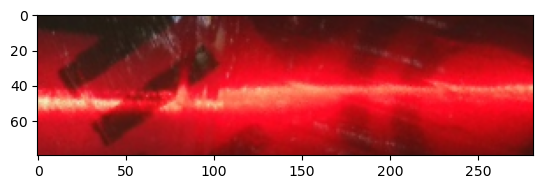

In [7]:

empty_path = folder + photos[2420-149]
full_path = folder + photos[1946-149]
random_path = folder + photos[20]
random_img = (preprocess_image(random_path, degree = 26.2))
plt.clf()
print(random_path)
plt.imshow(random_img[:, :, ::-1])
plt.show()


In [8]:
def high_pass(img, i = 9):
    
    low = cv2.GaussianBlur(img, (0, 0), sigmaX=3)
    if(i == 0):
        return img - low
    else:
        return high_pass(img, i-1)

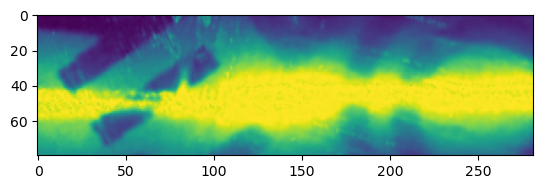

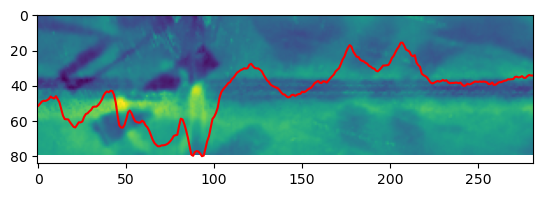

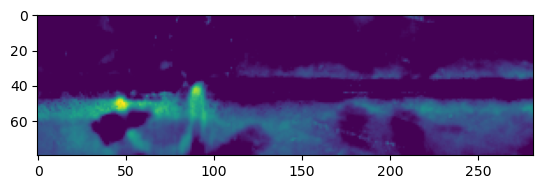

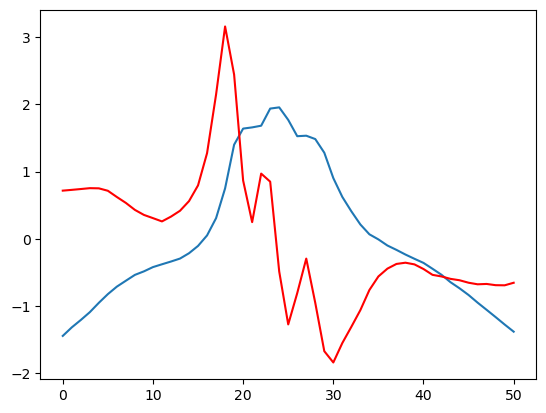

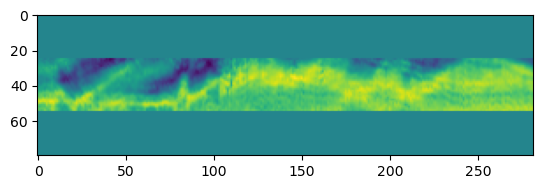

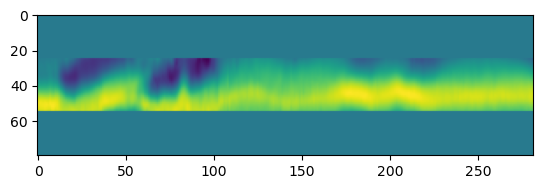

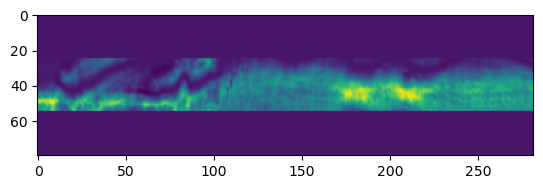

In [9]:
empty_gray = (to_gray(preprocess_image(empty_path, degree=26.2)))
random_gray = (to_gray(preprocess_image(random_path, degree=26.2)))
plt.imshow(random_gray)
plt.show()
img, score = background_residual_map(random_gray, empty_gray)
plt.clf()
plt.imshow(img)
plt.plot((score * 80/np.max(score)), color = "red")
plt.show()
positive_residual_img = np.maximum(img, 0)
plt.imshow(positive_residual_img)
plt.show()
radius = 25
template = make_general_laser_template(empty_gray, radius = radius)
grad = make_general_laser_template(empty_gray, use_derivative=True, radius=radius)
plt.plot(template)
plt.plot(grad, color = "red")
plt.show()
corr_img = np.zeros_like(img)
corr_img2 = np.zeros_like(img)
for i in range(img.shape[1]):
    corr_img[radius:-radius, i] = match_template_1d_column(random_gray[:, i], grad, True)
    corr_img2[radius:-radius, i] = match_template_1d_column(random_gray[:, i], template, False)

plt.imshow(corr_img)
plt.show()
plt.imshow(corr_img2)
plt.show()
plt.imshow(corr_img * corr_img2)




In [10]:
def smoothstep(x, lo, hi):
    x = np.clip((x - lo) / (hi - lo + 1e-9), 0, 1)
    return x * x * (3 - 2 * x)


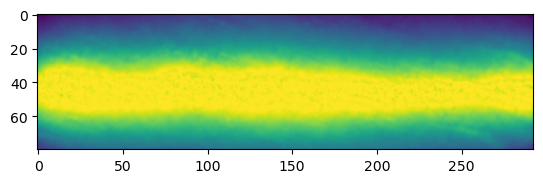

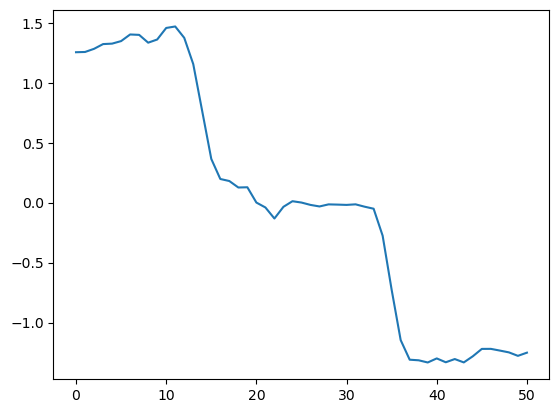

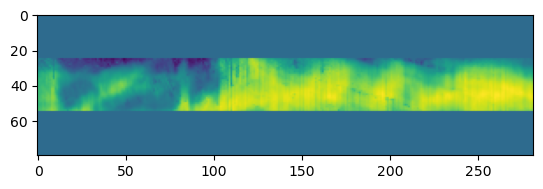

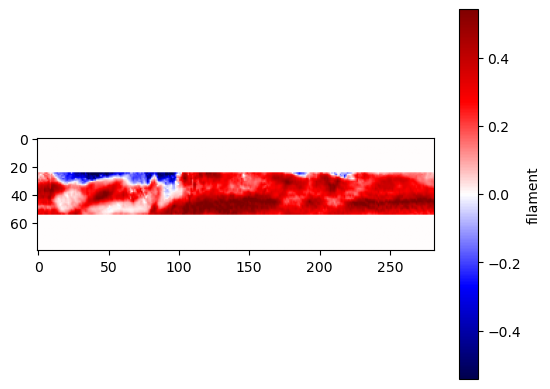

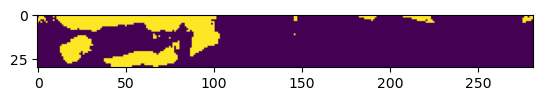

In [11]:
full_gray = to_gray(preprocess_image(full_path, degree=26.2))
plt.imshow(full_gray)
plt.show()
full_grad = make_general_laser_template(full_gray, use_derivative=True, radius=radius)
plt.plot(full_grad)
plt.show()
full_corr_img = np.zeros_like(img)
for i in range(img.shape[1]):
    full_corr_img[radius:-radius, i] = match_template_1d_column(random_gray[:, i], full_grad, True)
plt.clf()
plt.imshow(full_corr_img)
plt.show()
combin = full_corr_img * (1-corr_img)
v = np.percentile(np.abs(combin), 99)

plt.imshow(
    combin,
    cmap="seismic",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)
plt.colorbar(label="filament")
plt.show()
plt.imshow(combin[radius:-radius, :] < .1)
plt.show()

In [12]:
np.percentile(np.abs(combin[radius:-radius]), 6)


np.float64(0.05322833264227363)